# A2C 训练结果分析

本 notebook 用于分析 A2C 智能体的训练结果

## 1. 环境设置与数据加载

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12

print('库导入成功！')

库导入成功！


In [14]:
# 设置数据路径（相对于 notebooks/ 目录）
RESULTS_DIR = os.path.join('..', 'checkpoints-and-logs', 'local', 'A2C_2026_04_16-00_28', 'results')

# 加载 CSV 文件
train_df = pd.read_csv(os.path.join(RESULTS_DIR, 'training_metrics.csv'), parse_dates=['timestamp'])
eval_df  = pd.read_csv(os.path.join(RESULTS_DIR, 'evaluation_metrics.csv'), parse_dates=['timestamp'])

print(f'训练数据：{len(train_df)} 条记录')
print(f'评估数据：{len(eval_df)} 条记录')

训练数据：14000 条记录
评估数据：14000 条记录


## 2. 数据概览

In [16]:
print('=== 训练指标（前 5 行）===')
train_df.head()

=== 训练指标（前 5 行）===


,iteration,mean_reward,std_reward,min_reward,max_reward,mean_pegs_left,timestamp
0,0,0.786452,0.057665,0.728786,0.844117,7.62,2026-04-16 00:28:39.278550
1,1,0.792258,0.054423,0.737835,0.846682,7.44,2026-04-16 00:28:39.826122
2,2,0.789032,0.063610,0.725422,0.852642,7.54,2026-04-16 00:28:40.275810
3,3,0.788387,0.063265,0.725122,0.851652,7.56,2026-04-16 00:28:40.845012
4,4,0.790968,0.058150,0.732817,0.849118,7.48,2026-04-16 00:28:41.399578


In [17]:
print('=== 评估指标（前 5 行）===')
eval_df.head()

=== 评估指标（前 5 行）===


,iteration,eval_mean_reward,eval_std_reward,eval_mean_pegs_left,greedy_reward,greedy_pegs_left,timestamp
0,0,0.786452,0.057665,7.62,0.806452,7.0,2026-04-16 00:28:39.278550
1,1,0.792258,0.054423,7.44,0.806452,7.0,2026-04-16 00:28:39.826122
2,2,0.789032,0.063610,7.54,0.806452,7.0,2026-04-16 00:28:40.275810
3,3,0.788387,0.063265,7.56,0.806452,7.0,2026-04-16 00:28:40.845012
4,4,0.790968,0.058150,7.48,0.806452,7.0,2026-04-16 00:28:41.399578


In [18]:
print('=== 训练数据统计摘要 ===')
train_df.describe()

=== 训练数据统计摘要 ===


,iteration,mean_reward,std_reward,min_reward,max_reward,mean_pegs_left,timestamp
count,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000
mean,6999.500000,0.863552,0.049378,0.814174,0.912929,5.231784,2026-04-16 03:54:20.529885952
min,0.000000,0.752903,0.009677,0.607802,0.818517,3.020000,2026-04-16 00:28:39.278550
25%,3499.750000,0.831613,0.041006,0.775300,0.887726,3.980000,2026-04-16 03:01:35.885404672
50%,6999.500000,0.863871,0.048862,0.813265,0.916174,5.220000,2026-04-16 03:29:13.291179008
75%,10499.250000,0.903871,0.055123,0.860823,0.944974,6.240000,2026-04-16 03:58:51.989506304
max,13999.000000,0.939355,0.188312,0.922581,1.088252,8.660000,2026-04-16 09:25:00.119217
std,4041.596219,0.042215,0.015846,0.053475,0.034739,1.308083,NaN


In [19]:
print('=== 评估数据统计摘要 ===')
eval_df.describe()

=== 评估数据统计摘要 ===


,iteration,eval_mean_reward,eval_std_reward,eval_mean_pegs_left,greedy_reward,greedy_pegs_left,timestamp
count,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000.000000,14000
mean,6999.500000,0.863552,0.049378,5.231784,0.880263,4.711857,2026-04-16 03:54:20.529885952
min,0.000000,0.752903,0.009677,3.020000,0.677419,2.000000,2026-04-16 00:28:39.278550
25%,3499.750000,0.831613,0.041006,3.980000,0.838710,3.000000,2026-04-16 03:01:35.885404672
50%,6999.500000,0.863871,0.048862,5.220000,0.870968,5.000000,2026-04-16 03:29:13.291179008
75%,10499.250000,0.903871,0.055123,6.240000,0.935484,6.000000,2026-04-16 03:58:51.989506304
max,13999.000000,0.939355,0.188312,8.660000,0.967742,11.000000,2026-04-16 09:25:00.119217
std,4041.596219,0.042215,0.015846,1.308083,0.052736,1.634807,NaN


## 3. 训练曲线：Reward 变化

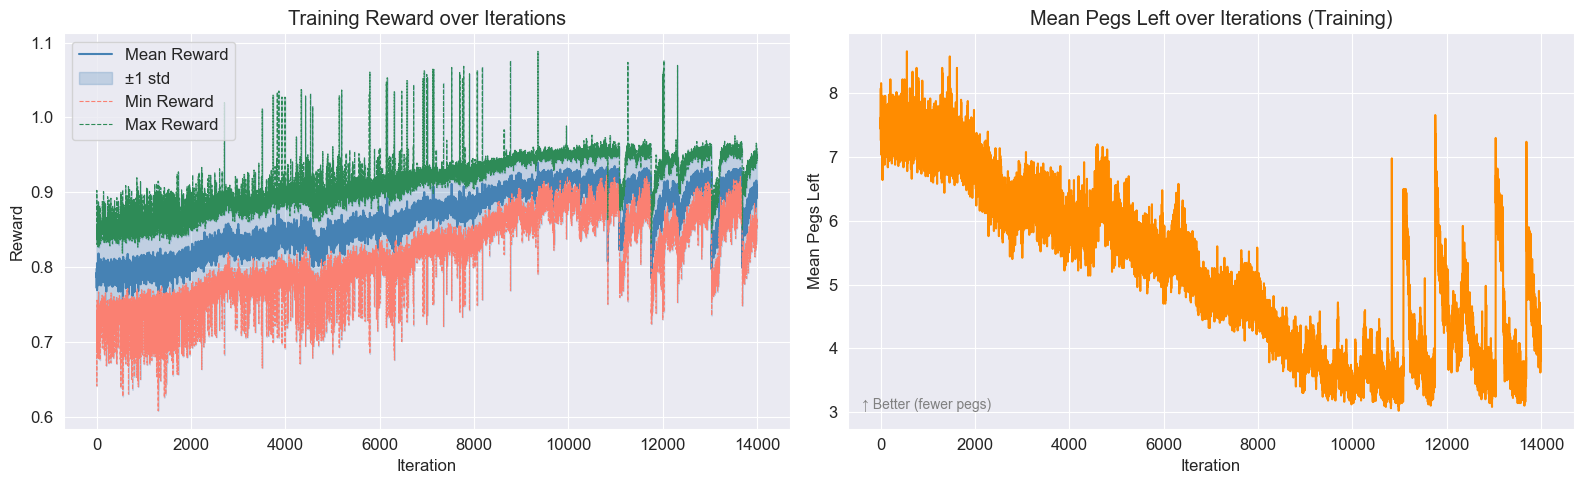


训练 Mean Reward 范围：0.7529 ~ 0.9394
最终（末 100 次迭代）Mean Reward 均值：0.8969
训练 Mean Pegs Left 范围：3.02 ~ 8.66
最终（末 100 次迭代）Mean Pegs Left 均值：4.20


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：训练平均 Reward
ax = axes[0]
ax.plot(train_df['iteration'], train_df['mean_reward'], color='steelblue', lw=1.5, label='Mean Reward')
ax.fill_between(
    train_df['iteration'],
    train_df['mean_reward'] - train_df['std_reward'],
    train_df['mean_reward'] + train_df['std_reward'],
    alpha=0.25, color='steelblue', label='±1 std'
)
ax.plot(train_df['iteration'], train_df['min_reward'], color='salmon', lw=0.8, linestyle='--', label='Min Reward')
ax.plot(train_df['iteration'], train_df['max_reward'], color='seagreen', lw=0.8, linestyle='--', label='Max Reward')
ax.set_xlabel('Iteration')
ax.set_ylabel('Reward')
ax.set_title('Training Reward over Iterations')
ax.legend()

# 右图：训练平均剩余棋子数
ax = axes[1]
ax.plot(train_df['iteration'], train_df['mean_pegs_left'], color='darkorange', lw=1.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Pegs Left')
ax.set_title('Mean Pegs Left over Iterations (Training)')
# ax.invert_yaxis()  # 棋子越少越好，反转 Y 轴方便直观理解
ax.annotate('↑ Better (fewer pegs)', xy=(0.02, 0.05), xycoords='axes fraction', fontsize=10, color='gray')

plt.tight_layout()
plt.show()

print(f'\n训练 Mean Reward 范围：{train_df["mean_reward"].min():.4f} ~ {train_df["mean_reward"].max():.4f}')
print(f'最终（末 100 次迭代）Mean Reward 均值：{train_df["mean_reward"].tail(100).mean():.4f}')
print(f'训练 Mean Pegs Left 范围：{train_df["mean_pegs_left"].min():.2f} ~ {train_df["mean_pegs_left"].max():.2f}')
print(f'最终（末 100 次迭代）Mean Pegs Left 均值：{train_df["mean_pegs_left"].tail(100).mean():.2f}')

## 4. 评估曲线

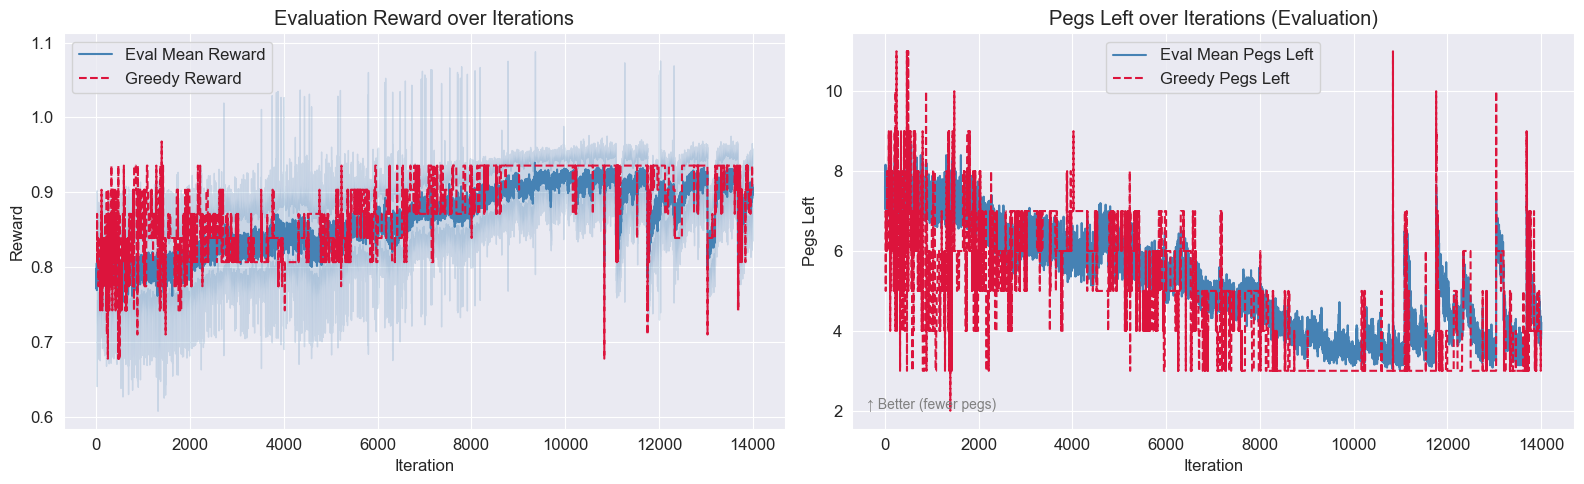


评估 Mean Reward 范围：0.7529 ~ 0.9394
Greedy Reward 范围：0.6774 ~ 0.9677
评估 Mean Pegs Left 范围：3.02 ~ 8.66
Greedy Pegs Left 范围：2 ~ 11


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图：Eval Mean Reward vs Greedy Reward
ax = axes[0]
ax.plot(eval_df['iteration'], eval_df['eval_mean_reward'], color='steelblue', lw=1.5, label='Eval Mean Reward')
ax.plot(eval_df['iteration'], eval_df['greedy_reward'], color='crimson', lw=1.5, linestyle='--', label='Greedy Reward')
ax.fill_between(
    eval_df['iteration'],
    eval_df['eval_mean_reward'] - eval_df['eval_std_reward'],
    eval_df['eval_mean_reward'] + eval_df['eval_std_reward'],
    alpha=0.2, color='steelblue'
)
ax.set_xlabel('Iteration')
ax.set_ylabel('Reward')
ax.set_title('Evaluation Reward over Iterations')
ax.legend()

# 右图：Eval Mean Pegs Left vs Greedy Pegs Left
ax = axes[1]
ax.plot(eval_df['iteration'], eval_df['eval_mean_pegs_left'], color='steelblue', lw=1.5, label='Eval Mean Pegs Left')
ax.plot(eval_df['iteration'], eval_df['greedy_pegs_left'], color='crimson', lw=1.5, linestyle='--', label='Greedy Pegs Left')
ax.set_xlabel('Iteration')
ax.set_ylabel('Pegs Left')
ax.set_title('Pegs Left over Iterations (Evaluation)')
# ax.invert_yaxis()
ax.annotate('↑ Better (fewer pegs)', xy=(0.02, 0.05), xycoords='axes fraction', fontsize=10, color='gray')
ax.legend()

plt.tight_layout()
plt.show()

print(f'\n评估 Mean Reward 范围：{eval_df["eval_mean_reward"].min():.4f} ~ {eval_df["eval_mean_reward"].max():.4f}')
print(f'Greedy Reward 范围：{eval_df["greedy_reward"].min():.4f} ~ {eval_df["greedy_reward"].max():.4f}')
print(f'评估 Mean Pegs Left 范围：{eval_df["eval_mean_pegs_left"].min():.2f} ~ {eval_df["eval_mean_pegs_left"].max():.2f}')
print(f'Greedy Pegs Left 范围：{eval_df["greedy_pegs_left"].min():.0f} ~ {eval_df["greedy_pegs_left"].max():.0f}')

## 5. 最佳迭代分析

In [22]:
# 最高 Mean Reward 的迭代
best_train_reward_idx = train_df['mean_reward'].idxmax()
best_train_row = train_df.loc[best_train_reward_idx]
print('=== 训练最佳 Mean Reward ===')
print(f'Iteration: {best_train_row["iteration"]}')
print(f'Mean Reward: {best_train_row["mean_reward"]:.4f}')
print(f'Mean Pegs Left: {best_train_row["mean_pegs_left"]:.2f}')
print()

# 最少剩余棋子的迭代
best_train_pegs_idx = train_df['mean_pegs_left'].idxmin()
best_train_pegs_row = train_df.loc[best_train_pegs_idx]
print('=== 训练最少 Mean Pegs Left ===')
print(f'Iteration: {best_train_pegs_row["iteration"]}')
print(f'Mean Reward: {best_train_pegs_row["mean_reward"]:.4f}')
print(f'Mean Pegs Left: {best_train_pegs_row["mean_pegs_left"]:.2f}')
print()

# 评估最佳 Greedy Reward
best_greedy_idx = eval_df['greedy_reward'].idxmax()
best_greedy_row = eval_df.loc[best_greedy_idx]
print('=== 评估最佳 Greedy Reward ===')
print(f'Iteration: {best_greedy_row["iteration"]}')
print(f'Greedy Reward: {best_greedy_row["greedy_reward"]:.4f}')
print(f'Greedy Pegs Left: {best_greedy_row["greedy_pegs_left"]:.0f}')
print()

# 评估最少 Greedy Pegs Left
best_greedy_pegs_idx = eval_df['greedy_pegs_left'].idxmin()
best_greedy_pegs_row = eval_df.loc[best_greedy_pegs_idx]
print('=== 评估最少 Greedy Pegs Left ===')
print(f'Iteration: {best_greedy_pegs_row["iteration"]}')
print(f'Greedy Reward: {best_greedy_pegs_row["greedy_reward"]:.4f}')
print(f'Greedy Pegs Left: {best_greedy_pegs_row["greedy_pegs_left"]:.0f}')

=== 训练最佳 Mean Reward ===
Iteration: 9357
Mean Reward: 0.9394
Mean Pegs Left: 3.48

=== 训练最少 Mean Pegs Left ===
Iteration: 10983
Mean Reward: 0.9348
Mean Pegs Left: 3.02

=== 评估最佳 Greedy Reward ===
Iteration: 1393
Greedy Reward: 0.9677
Greedy Pegs Left: 2

=== 评估最少 Greedy Pegs Left ===
Iteration: 1393
Greedy Reward: 0.9677
Greedy Pegs Left: 2


## 6. 训练进展：早期 vs 中期 vs 末期

In [10]:
n = len(train_df)
early   = train_df.iloc[:n//10]
middle  = train_df.iloc[n//10*4 : n//10*6]
late    = train_df.iloc[-n//10:]

stages = {
    '早期（前 10%）':  early,
    '中期（40%~60%）': middle,
    '末期（后 10%）':  late,
}

print(f'{'阶段':<18} | {'Mean Reward':>14} | {'Std Reward':>12} | {'Mean Pegs Left':>16}')
print('-' * 68)
for stage_name, df_stage in stages.items():
    mr  = df_stage['mean_reward'].mean()
    sr  = df_stage['std_reward'].mean()
    mpl = df_stage['mean_pegs_left'].mean()
    print(f'{stage_name:<18} | {mr:>14.4f} | {sr:>12.4f} | {mpl:>16.2f}')

SyntaxError: f-string: expecting '}' (1591006332.py, line 12)

## 7. 奖励分布（末期 10%）

/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/2705937853.py:24: UserWarning: Glyph 26411 (\N{CJK UNIFIED IDEOGRAPH-672B}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/2705937853.py:24: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  plt.tight_layout()
/Users/kongyunzhi/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26411 (\N{CJK UNIFIED IDEOGRAPH-672B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kongyunzhi/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


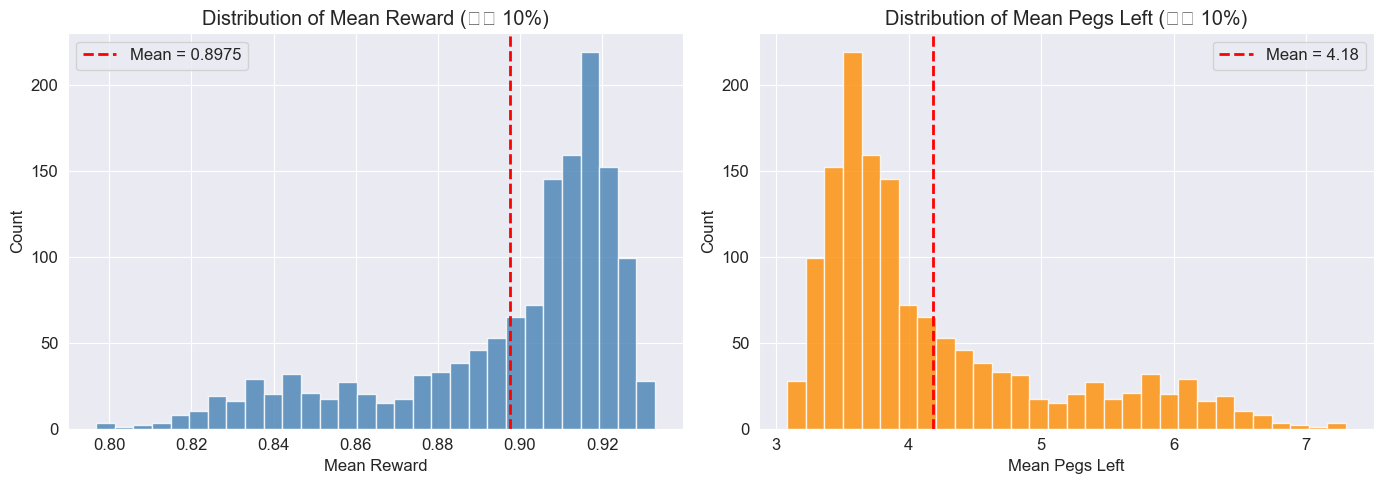

In [23]:
n = len(train_df)
late_train = train_df.iloc[-n//10:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 末期 Mean Reward 分布
ax = axes[0]
ax.hist(late_train['mean_reward'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(late_train['mean_reward'].mean(), color='red', linestyle='--', lw=2, label=f'Mean = {late_train["mean_reward"].mean():.4f}')
ax.set_xlabel('Mean Reward')
ax.set_ylabel('Count')
ax.set_title('Distribution of Mean Reward (末期 10%)')
ax.legend()

# 末期 Mean Pegs Left 分布
ax = axes[1]
ax.hist(late_train['mean_pegs_left'], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
ax.axvline(late_train['mean_pegs_left'].mean(), color='red', linestyle='--', lw=2, label=f'Mean = {late_train["mean_pegs_left"].mean():.2f}')
ax.set_xlabel('Mean Pegs Left')
ax.set_ylabel('Count')
ax.set_title('Distribution of Mean Pegs Left (末期 10%)')
ax.legend()

plt.tight_layout()
plt.show()

## 8. 平滑曲线（移动平均）

移动平均窗口大小：140


/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/1211606055.py:28: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/1211606055.py:28: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/1211606055.py:28: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/1211606055.py:28: UserWarning: Glyph 28369 (\N{CJK UNIFIED IDEOGRAPH-6ED1}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/ipykernel_76795/1211606055.py:28: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/nc/77k04l2944g1x5dbl07tt8vr0000gp/T/i

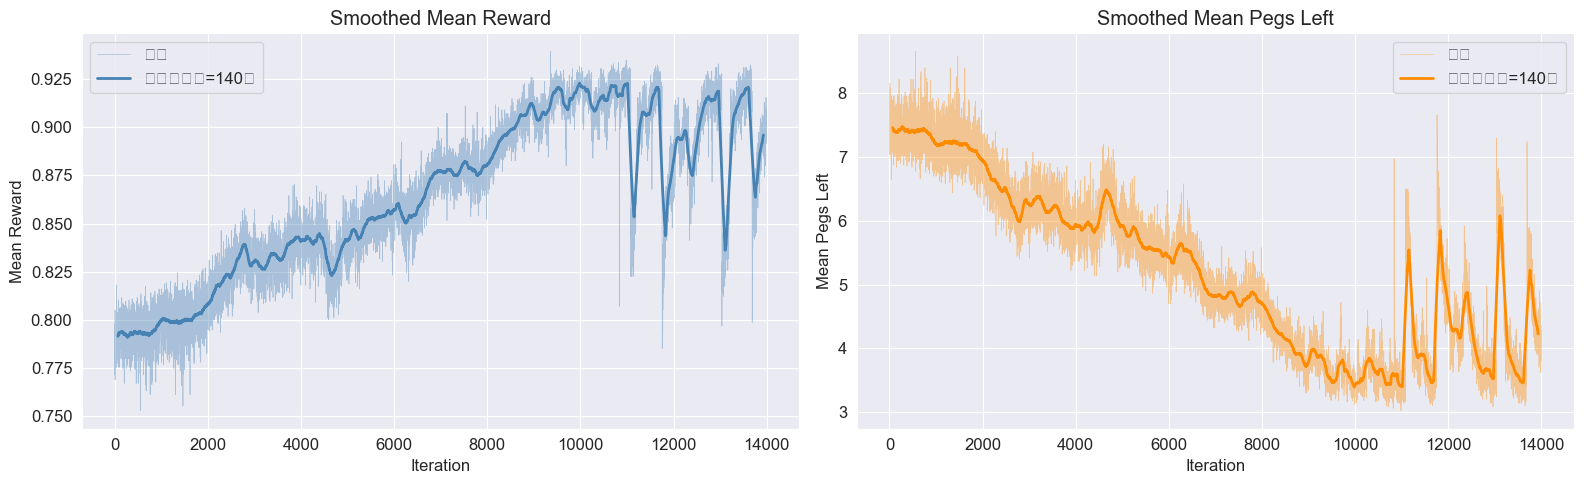

In [29]:
WINDOW = max(1, len(train_df) // 100)  # 约 1% 的窗口大小
print(f'移动平均窗口大小：{WINDOW}')

train_df['smooth_mean_reward']    = train_df['mean_reward'].rolling(window=WINDOW, center=True).mean()
train_df['smooth_mean_pegs_left'] = train_df['mean_pegs_left'].rolling(window=WINDOW, center=True).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 平滑 Reward
ax = axes[0]
ax.plot(train_df['iteration'], train_df['mean_reward'], color='steelblue', lw=0.5, alpha=0.4, label='原始')
ax.plot(train_df['iteration'], train_df['smooth_mean_reward'], color='steelblue', lw=2, label=f'平滑（窗口={WINDOW}）')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Reward')
ax.set_title('Smoothed Mean Reward')
ax.legend()

# 平滑 Pegs Left
ax = axes[1]
ax.plot(train_df['iteration'], train_df['mean_pegs_left'], color='darkorange', lw=0.5, alpha=0.4, label='原始')
ax.plot(train_df['iteration'], train_df['smooth_mean_pegs_left'], color='darkorange', lw=2, label=f'平滑（窗口={WINDOW}）')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Pegs Left')
ax.set_title('Smoothed Mean Pegs Left')
# ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.show()

## 9. 综合仪表板

/Users/kongyunzhi/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26411 (\N{CJK UNIFIED IDEOGRAPH-672B}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kongyunzhi/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


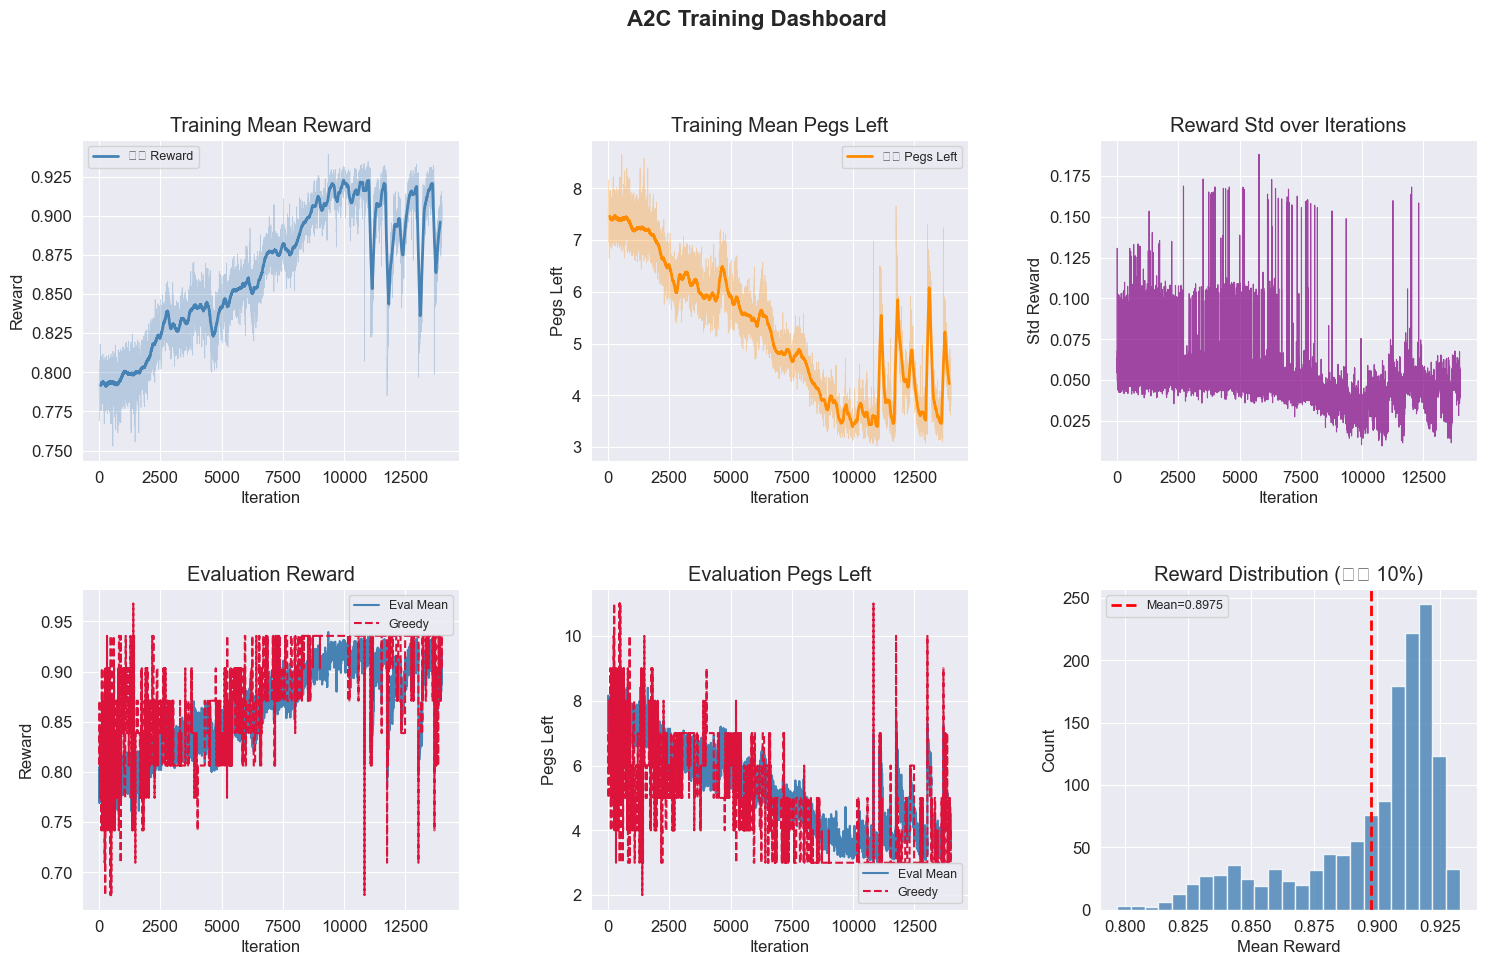

In [30]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# (0,0) 训练 Reward 曲线（带平滑）
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(train_df['iteration'], train_df['mean_reward'], color='steelblue', lw=0.5, alpha=0.3)
ax1.plot(train_df['iteration'], train_df['smooth_mean_reward'], color='steelblue', lw=2, label='平滑 Reward')
ax1.set_title('Training Mean Reward')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Reward')
ax1.legend(fontsize=9)

# (0,1) 训练 Pegs Left 曲线（带平滑）
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(train_df['iteration'], train_df['mean_pegs_left'], color='darkorange', lw=0.5, alpha=0.3)
ax2.plot(train_df['iteration'], train_df['smooth_mean_pegs_left'], color='darkorange', lw=2, label='平滑 Pegs Left')
ax2.set_title('Training Mean Pegs Left')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Pegs Left')
# ax2.invert_yaxis()
ax2.legend(fontsize=9)

# (0,2) Reward 方差变化
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(train_df['iteration'], train_df['std_reward'], color='purple', lw=0.8, alpha=0.7)
ax3.set_title('Reward Std over Iterations')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Std Reward')

# (1,0) 评估 Reward：Eval vs Greedy
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(eval_df['iteration'], eval_df['eval_mean_reward'], color='steelblue', lw=1.5, label='Eval Mean')
ax4.plot(eval_df['iteration'], eval_df['greedy_reward'], color='crimson', lw=1.5, linestyle='--', label='Greedy')
ax4.set_title('Evaluation Reward')
ax4.set_xlabel('Iteration')
ax4.set_ylabel('Reward')
ax4.legend(fontsize=9)

# (1,1) 评估 Pegs Left：Eval vs Greedy
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(eval_df['iteration'], eval_df['eval_mean_pegs_left'], color='steelblue', lw=1.5, label='Eval Mean')
ax5.plot(eval_df['iteration'], eval_df['greedy_pegs_left'], color='crimson', lw=1.5, linestyle='--', label='Greedy')
ax5.set_title('Evaluation Pegs Left')
ax5.set_xlabel('Iteration')
ax5.set_ylabel('Pegs Left')
# ax5.invert_yaxis()
ax5.legend(fontsize=9)

# (1,2) 末期 Reward 分布
n = len(train_df)
late_train = train_df.iloc[-n//10:]
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(late_train['mean_reward'], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
ax6.axvline(late_train['mean_reward'].mean(), color='red', linestyle='--', lw=2,
            label=f'Mean={late_train["mean_reward"].mean():.4f}')
ax6.set_title('Reward Distribution (末期 10%)')
ax6.set_xlabel('Mean Reward')
ax6.set_ylabel('Count')
ax6.legend(fontsize=9)

fig.suptitle('A2C Training Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.show()

## 10. 训练总结

In [31]:
n = len(train_df)
late_train = train_df.iloc[-n//10:]

total_duration = (train_df['timestamp'].max() - train_df['timestamp'].min()).total_seconds()

best_greedy_pegs_idx = eval_df['greedy_pegs_left'].idxmin()
best_greedy_pegs_row = eval_df.loc[best_greedy_pegs_idx]

best_greedy_reward_idx = eval_df['greedy_reward'].idxmax()
best_greedy_reward_row = eval_df.loc[best_greedy_reward_idx]

print('='*60)
print('         A2C 训练结果总结')
print('='*60)
print(f'总迭代次数       : {len(train_df)}')
print(f'总训练时长       : {total_duration:.1f} 秒 ({total_duration/60:.1f} 分钟)')
print()
print(f'--- 训练指标 ---')
print(f'早期 Mean Reward  : {train_df["mean_reward"].head(n//10).mean():.4f}')
print(f'末期 Mean Reward  : {late_train["mean_reward"].mean():.4f}')
print(f'最高 Mean Reward  : {train_df["mean_reward"].max():.4f}  (iter={train_df["mean_reward"].idxmax()})')
print(f'早期 Mean Pegs    : {train_df["mean_pegs_left"].head(n//10).mean():.2f}')
print(f'末期 Mean Pegs    : {late_train["mean_pegs_left"].mean():.2f}')
print(f'最少 Mean Pegs    : {train_df["mean_pegs_left"].min():.2f}  (iter={train_df["mean_pegs_left"].idxmin()})')
print()
print(f'--- 评估指标 ---')
print(f'最佳 Greedy Reward: {best_greedy_reward_row["greedy_reward"]:.4f}  (iter={best_greedy_reward_row["iteration"]})')
print(f'最少 Greedy Pegs  : {best_greedy_pegs_row["greedy_pegs_left"]:.0f}      (iter={best_greedy_pegs_row["iteration"]})')
print()
print(f'--- 关键观察 ---')
reward_improvement = late_train['mean_reward'].mean() - train_df['mean_reward'].head(n//10).mean()
pegs_improvement   = train_df['mean_pegs_left'].head(n//10).mean() - late_train['mean_pegs_left'].mean()
print(f'Reward 提升       : {reward_improvement:+.4f}')
print(f'Pegs Left 减少    : {pegs_improvement:+.2f}')
print('='*60)

         A2C 训练结果总结
总迭代次数       : 14000
总训练时长       : 32180.8 秒 (536.3 分钟)

--- 训练指标 ---
早期 Mean Reward  : 0.7952
末期 Mean Reward  : 0.8975
最高 Mean Reward  : 0.9394  (iter=9357)
早期 Mean Pegs    : 7.35
末期 Mean Pegs    : 4.18
最少 Mean Pegs    : 3.02  (iter=10983)

--- 评估指标 ---
最佳 Greedy Reward: 0.9677  (iter=1393)
最少 Greedy Pegs  : 2      (iter=1393)

--- 关键观察 ---
Reward 提升       : +0.1023
Pegs Left 减少    : +3.17
